<a href="https://colab.research.google.com/github/code10-td/Deep-learning/blob/main/mango_leaf_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

#Preparing The Data

In [ ]:
from google.colab import files
import zipfile
import pathlib

# Upload the ZIP file from your PC
uploaded = files.upload()

# Extract the ZIP file
with zipfile.ZipFile("/content/Mango_Leaf_Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content")

# Dataset path
data_dir = pathlib.Path("/content/Mango_Leaf_Dataset")

# Check if the dataset was loaded successfully
print("Dataset path:", data_dir)

for folder in data_dir.iterdir():
    print(folder)

Saving Mango_Leaf_Dataset.zip to Mango_Leaf_Dataset.zip
Dataset path: /content/Mango_Leaf_Dataset
/content/Mango_Leaf_Dataset/Powdery_Mildew
/content/Mango_Leaf_Dataset/Cutting_Weevil
/content/Mango_Leaf_Dataset/Anthracnose
/content/Mango_Leaf_Dataset/Healthy
/content/Mango_Leaf_Dataset/Bacterial_Canker


In [ ]:
print(data_dir)

/content/Mango_Leaf_Dataset


/content/Mango_Leaf_Dataset/Healthy/Healthy (18).jpg


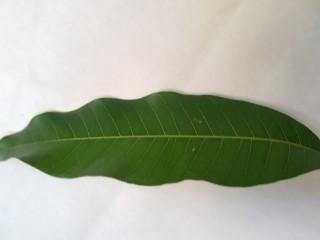

In [ ]:
Healthy = list(data_dir.glob('Healthy/*'))
print(Healthy[20])
PIL.Image.open(str(Healthy[20]))

In [ ]:
img_height,img_width=180,180
batch_size=32
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='categorical')

def preprocess_image(image, label):
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess_image)

Found 500 files belonging to 5 classes.
Using 400 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='categorical')

def preprocess_image(image, label):
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

val_ds = val_ds.map(preprocess_image)

Found 500 files belonging to 5 classes.
Using 100 files for validation.


In [ ]:
import os
class_names = sorted([item.name for item in data_dir.iterdir() if item.is_dir()])
print(class_names)

['Anthracnose', 'Bacterial_Canker', 'Cutting_Weevil', 'Healthy', 'Powdery_Mildew']


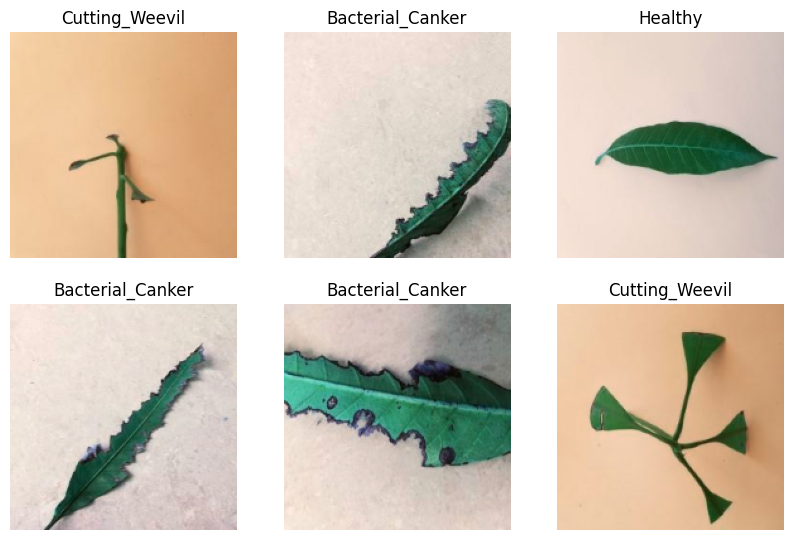

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf # Ensure tf is imported for argmax

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(6):
    ax = plt.subplot(3, 3, i + 1)

    # Fix for image display: scale preprocessed image values for visualization
    image_to_display = images[i].numpy()
    # Normalize to [0, 1] based on its current min/max for better visualization
    image_to_display = (image_to_display - image_to_display.min()) / (image_to_display.max() - image_to_display.min())
    plt.imshow(image_to_display)

    # Fix for label error: labels are one-hot encoded, convert to integer index
    class_index = tf.argmax(labels[i]).numpy()
    plt.title(class_names[class_index])
    plt.axis("off")

In [ ]:
resnet_model = Sequential()

pretrained_model= tf.keras.applications.ResNet50(include_top=False,
                   input_shape=(180,180,3),
                   pooling='avg',
                   weights='imagenet')
for layer in pretrained_model.layers:
        layer.trainable=False

resnet_model.add(pretrained_model)
resnet_model.add(layers.Flatten())
resnet_model.add(layers.Dense(512, activation='relu'))
resnet_model.add(layers.Dense(5, activation='softmax')) # Ensure this is 6

resnet_model.summary() # Added to verify the model's output shape

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,639,365 (93.99 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,639,365 (93.99 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
epochs=10
resnet_model.build(input_shape=(None, 180, 180, 3)) # Explicitly build the model
history = resnet_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 6s/step - accuracy: 0.8350 - loss: 0.5023 - val_accuracy: 0.9800 - val_loss: 0.0601
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 61s 5s/step - accuracy: 0.9875 - loss: 0.0521 - val_accuracy: 1.0000 - val_loss: 0.0095
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step - accuracy: 0.9975 - loss: 0.0044 - val_accuracy: 0.9900 - val_loss: 0.0210
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 89s 5s/step - accuracy: 1.0000 - loss: 6.4686e-04 - val_accuracy: 0.9900 - val_loss: 0.0123
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 59s 5s/step - accuracy: 1.0000 - loss: 3.8594e-04 - val_accuracy: 0.9900 - val_loss: 0.0114
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 83s 5s/step - accuracy: 1.0000 - loss: 2.5640e-04 - val_accuracy: 0.9900 - val_loss: 0.0111
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 84s 5s/step - accuracy: 1.0000 - loss: 1.9119e-04 - val_accuracy: 0.9900 - val_loss: 0.0109
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 69s 5s/step - accuracy: 1.0000 - loss: 1.6900e-04 - val_accuracy

#Evaluating The Model

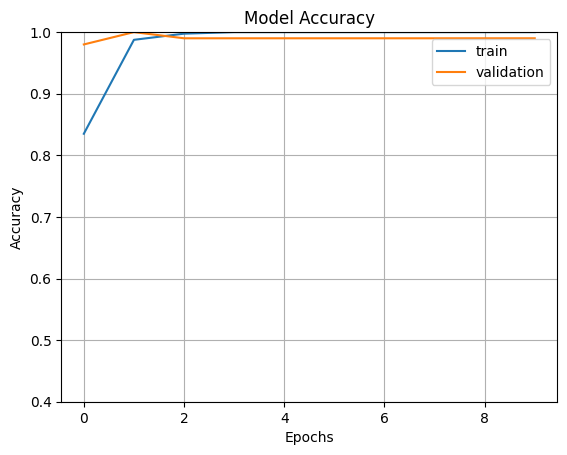

In [ ]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

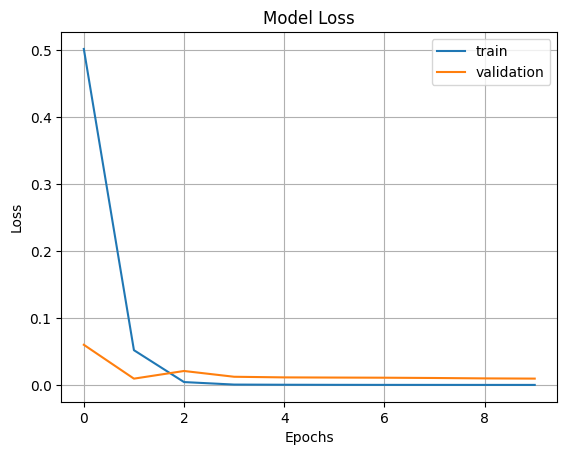

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

#Making Predictions

In [ ]:
import cv2
image=cv2.imread(str(Healthy[0]))
image_resized= cv2.resize(image, (img_height,img_width))
image=np.expand_dims(image_resized,axis=0)
print(image.shape)

(1, 180, 180, 3)


In [ ]:
pred=resnet_model.predict(image)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[7.5530593e-04 1.5079137e-07 1.8913691e-09 9.9924040e-01 4.1585922e-06]]


In [ ]:
output_class=class_names[np.argmax(pred)]
print("The predicted class is", output_class)

The predicted class is Healthy
